In [8]:
import os
import numpy as np
import pandas as pd
from PIL import Image
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator

DATASET_PATH = r"C:\Users\94772\Desktop\Abdullah_project\Tamil_Character_Recognition\dataset_raw"
IMG_SIZE = (128,128)
BATCH_SIZE = 32



## Create Train / Validation / Test Datasets


In [46]:
import tensorflow as tf

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.3,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.3,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = val_test_ds.take( int(0.5 * len(val_test_ds)) )
test_ds = val_test_ds.skip( int(0.5 * len(val_test_ds)) )


Found 24700 files belonging to 247 classes.
Using 17290 files for training.
Found 24700 files belonging to 247 classes.
Using 7410 files for validation.


In [47]:
#Normalize
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds   = val_ds.map(lambda x, y: (normalization_layer(x), y))
test_ds  = test_ds.map(lambda x, y: (normalization_layer(x), y))


In [52]:

#  Performance optimization 
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds   = val_ds.prefetch(AUTOTUNE)
test_ds  = test_ds.prefetch(AUTOTUNE)

In [50]:
for images, labels in train_ds.take(1):
    print(images.dtype)
    print(images.shape)
    print(labels[:10])


<dtype: 'float32'>
(32, 128, 128, 3)
tf.Tensor([163 133  25 158 178 115  35 179 221 235], shape=(10,), dtype=int32)


In [49]:
for x, y in train_ds.take(1):
    print("min:", x.numpy().min(), "max:", x.numpy().max())


min: 0.0 max: 1.0


In [ ]:
import os

# Count folders = number of classes
class_names = [d for d in os.listdir(DATASET_PATH) 
               if os.path.isdir(os.path.join(DATASET_PATH, d))]

class_names = sorted(class_names)

NUM_CLASSES = len(class_names)

print("Total Classes =", NUM_CLASSES)


Total Classes = 247


## Model1

In [14]:
#Data Augmentation Layer
import tensorflow as tf

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.08),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.1)
])


In [16]:
num_classes = 247

model_1 = tf.keras.Sequential([
    
    tf.keras.layers.InputLayer(input_shape=(128,128,3)),   # 👈 ADD THIS

    data_augmentation,

    tf.keras.layers.Conv2D(32, (3,3), activation='relu', padding="same"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, (3,3), activation='relu', padding="same"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128, (3,3), activation='relu', padding="same"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.4),

    tf.keras.layers.Dense(num_classes, activation='softmax')
])

model_1.summary()


c:\Users\94772\anaconda3\Lib\site-packages\keras\src\layers\core\input_layer.py:26: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 247)            │        63,479 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,545,591 (32.60 MB)

 Trainable params: 8,545,591 (32.60 MB)

 Non-trainable params: 0 (0.00 B)

## Compile Model

In [17]:
model_1.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss = "sparse_categorical_crossentropy",
    metrics = ["accuracy"]
)


In [20]:
#Train Model
history_1 = model_1.fit(
    train_ds,
    validation_data = val_ds,
    epochs = 15
)


Epoch 1/15
541/541 ━━━━━━━━━━━━━━━━━━━━ 169s 304ms/step - accuracy: 0.0032 - loss: 5.5379 - val_accuracy: 0.0043 - val_loss: 5.4810
Epoch 2/15
541/541 ━━━━━━━━━━━━━━━━━━━━ 141s 261ms/step - accuracy: 0.0124 - loss: 5.2661 - val_accuracy: 0.0445 - val_loss: 4.5353
Epoch 3/15
541/541 ━━━━━━━━━━━━━━━━━━━━ 145s 268ms/step - accuracy: 0.0369 - loss: 4.6284 - val_accuracy: 0.1355 - val_loss: 3.6997
Epoch 4/15
541/541 ━━━━━━━━━━━━━━━━━━━━ 142s 263ms/step - accuracy: 0.0857 - loss: 4.0894 - val_accuracy: 0.2365 - val_loss: 3.1261
Epoch 5/15
541/541 ━━━━━━━━━━━━━━━━━━━━ 140s 258ms/step - accuracy: 0.1319 - loss: 3.6414 - val_accuracy: 0.3227 - val_loss: 2.6633
Epoch 6/15
541/541 ━━━━━━━━━━━━━━━━━━━━ 141s 261ms/step - accuracy: 0.1757 - loss: 3.3283 - val_accuracy: 0.3710 - val_loss: 2.4026
Epoch 7/15
541/541 ━━━━━━━━━━━━━━━━━━━━ 144s 265ms/step - accuracy: 0.2103 - loss: 3.1040 - val_accuracy: 0.4620 - val_loss: 2.0973
Epoch 8/15
541/541 ━━━━━━━━━━━━━━━━━━━━ 147s 272ms/step - accuracy: 0.2431 -

In [21]:
test_loss, test_acc = model_1.evaluate(test_ds)
print("Test Accuracy =", test_acc)
print("Test Loss =", test_loss)


116/116 ━━━━━━━━━━━━━━━━━━━━ 19s 142ms/step - accuracy: 0.6345 - loss: 1.3658
Test Accuracy = 0.6425094604492188
Test Loss = 1.3287854194641113


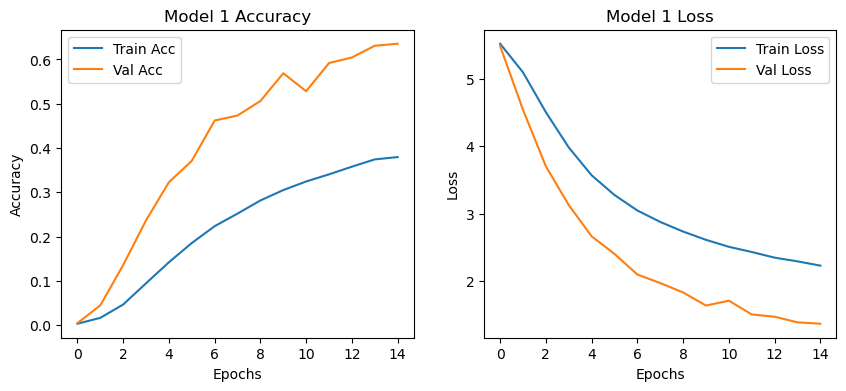

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history_1.history["accuracy"], label="Train Acc")
plt.plot(history_1.history["val_accuracy"], label="Val Acc")
plt.title("Model 1 Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history_1.history["loss"], label="Train Loss")
plt.plot(history_1.history["val_loss"], label="Val Loss")
plt.title("Model 1 Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.show()


In [24]:
model_1.save("model_1.keras")


## MODEL-2: Final Code

In [53]:
import os

# Count folders = number of classes
class_names = [d for d in os.listdir(DATASET_PATH) 
               if os.path.isdir(os.path.join(DATASET_PATH, d))]

class_names = sorted(class_names)

NUM_CLASSES = len(class_names)

print("Total Classes =", NUM_CLASSES)


Total Classes = 247


In [54]:
import tensorflow as tf
from tensorflow.keras import layers, models

inputs = layers.Input(shape=(128, 128, 3))

# ---- DATA AUGMENTATION ----
x = layers.RandomFlip("horizontal")(inputs)
x = layers.RandomRotation(0.10)(x)
x = layers.RandomZoom(0.1)(x)



# ---- CNN BLOCKS ----
x = layers.Conv2D(32, (3,3), activation='relu', padding="same")(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D()(x)

x = layers.Conv2D(64, (3,3), activation='relu', padding="same")(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D()(x)

x = layers.Conv2D(128, (3,3), activation='relu', padding="same")(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D()(x)

# ---- CLASSIFIER ----
x = layers.Flatten()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)

outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

model_2 = models.Model(inputs, outputs)

model_2.summary()


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip_7 (RandomFlip)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_7               │ (None, 128, 128, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_7 (RandomZoom)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_24 (MaxPooling2D) │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_25 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_26 (MaxPooling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 247)            │        63,479 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,546,487 (32.60 MB)

 Trainable params: 8,546,039 (32.60 MB)

 Non-trainable params: 448 (1.75 KB)

In [55]:
#complie
model_2.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


In [56]:
#callbacks
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "best_model_2.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)


In [57]:
history_2 = model_2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[checkpoint, early_stop]
)


Epoch 1/10
541/541 ━━━━━━━━━━━━━━━━━━━━ 0s 495ms/step - accuracy: 0.0035 - loss: 6.1698
Epoch 1: val_accuracy improved from -inf to 0.00323, saving model to best_model_2.keras
541/541 ━━━━━━━━━━━━━━━━━━━━ 283s 516ms/step - accuracy: 0.0035 - loss: 6.1688 - val_accuracy: 0.0032 - val_loss: 5.5109
Epoch 2/10
541/541 ━━━━━━━━━━━━━━━━━━━━ 0s 445ms/step - accuracy: 0.0028 - loss: 5.5108
Epoch 2: val_accuracy did not improve from 0.00323
541/541 ━━━━━━━━━━━━━━━━━━━━ 252s 466ms/step - accuracy: 0.0028 - loss: 5.5108 - val_accuracy: 0.0024 - val_loss: 5.5126
Epoch 3/10
195/541 ━━━━━━━━━━━━━━━━━━━━ 2:36 453ms/step - accuracy: 0.0047 - loss: 5.5103

KeyboardInterrupt: 

In [37]:
test_loss, test_acc = model_2.evaluate(test_ds)
print("Test Accuracy =", test_acc)
print("Test Loss =", test_loss)


116/116 ━━━━━━━━━━━━━━━━━━━━ 23s 172ms/step - accuracy: 0.0018 - loss: 5.5115
Test Accuracy = 0.0016224986175075173
Test Loss = 5.511663436889648


In [40]:
for images, labels in train_ds.take(1):
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)


Image batch shape: (32, 128, 128, 3)
Label batch shape: (32,)
